In [2]:
import pandas as pd

In [3]:
measurements_timeseries = pd.read_csv("measurements_analysis_ready.csv")
visits_thyroid = pd.read_csv("visits_analysis_ready.csv")

In [4]:
measurements_timeseries.head()

,person_id,gender_concept_id,gender_clean,year_of_birth,age_at_measurement,age_group,race_concept_id,race_clean,ethnicity_concept_id,ethnicity_clean,...,ALT,Serum_Creatinine,Serum_Albumin,tsh,t3,t4,has_tsh,has_t3,has_t4,has_any_thyroid_test
0,894170912,8507,M,1982.0,43.0,35-49,8527,White,38003564,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,191126884,8532,F,2003.0,22.0,18-34,0,Unknown,0,Unknown,...,NaN,0.93,NaN,NaN,NaN,NaN,0,0,0,0
2,101262469,8532,F,2013.0,12.0,0-17,8527,White,38003564,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
3,908390849,8507,M,1966.0,59.0,50-64,8516,Black or African American,38003564,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
4,939482390,8507,M,2007.0,18.0,18-34,8527,White,38003564,Not Hispanic or Latino,...,80.0,1.16,4.2,NaN,NaN,NaN,0,0,0,0


In [5]:
measurements_timeseries.info()

<class 'pandas.DataFrame'>
RangeIndex: 2913028 entries, 0 to 2913027
Data columns (total 29 columns):
 #   Column                Dtype  
---  ------                -----  
 0   person_id             int64  
 1   gender_concept_id     int64  
 2   gender_clean          str    
 3   year_of_birth         float64
 4   age_at_measurement    float64
 5   age_group             str    
 6   race_concept_id       int64  
 7   race_clean            str    
 8   ethnicity_concept_id  int64  
 9   ethnicity_clean       str    
 10  measurement_date      str    
 11  measurement_year      int64  
 12  measurement_month     str    
 13  weight                float64
 14  bmi                   float64
 15  triglycerides         float64
 16  hba1c                 float64
 17  Serum_Glucose         float64
 18  AST                   float64
 19  ALT                   float64
 20  Serum_Creatinine      float64
 21  Serum_Albumin         float64
 22  tsh                   float64
 23  t3                

In [6]:
visits_thyroid.head()

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


In [7]:
visits_thyroid.info()

<class 'pandas.DataFrame'>
RangeIndex: 179124 entries, 0 to 179123
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    179124 non-null  int64  
 1   gender_concept_id            179124 non-null  int64  
 2   gender                       179124 non-null  str    
 3   gender_clean                 179124 non-null  str    
 4   year_of_birth                178760 non-null  float64
 5   age_at_visit                 178760 non-null  float64
 6   age_group                    178760 non-null  str    
 7   race                         179124 non-null  str    
 8   race_clean                   179124 non-null  str    
 9   ethnicity                    179124 non-null  str    
 10  ethnicity_clean              179124 non-null  str    
 11  snomed_condition_concept_id  179124 non-null  int64  
 12  condition_description        179124 non-null  str    
 13  condition_

## For OR group, we're focusing on **Thyroid Conditions Cohort**

### **Bloodwork values involved with Thyroid are:**

**1. TSH (Thyroid-Stimulating Hormone)**
- measures hormone from pituitary gland that signals the thyroid
- HIGH TSH = UNDERactive thyroid = HYPOthyroidism
- LOW TSH = OVEReactive thyroid = HYPERthyroidism

**2. Free T3 (Thyroxine)**
- Often checked if HYPERthyroidism is suspected
- T3 can be HIGH while T4 remains normal

**3. Free T4 (Triiodothyronine)**
- MAIN hormone produced by thyroid gland
- often measured to confirm TSH results or confirm the severity and cause of the thyroid
    - helps to distinguish btw SUBCLINICAL & OVERT thyroid dysfunction
    - If TSH abnormal --> a free T4 measures the UNBOUND, active thyroid hormone to determine IF dysfunction lies WITHIN the thyroid gland OR the pituitatry gland

- **How Free T4 confirms TSH findings:**
    1. *Elevated TSH + LOW T4* = confirms primary HYPOthyroidism (UNDERACTIVE thyroid gland)
    2. *Low TSH + HIGH T4* = confirms primary HYPERthyroidism (OVEREACTIVE thyroid gland)
    3. *Elevated TSH + NORMAL T4* = suggests SUBCLINICAL HYPOthyroidism
        - indicated that pituitary is ACTING but thyroid is NOT yet failing significantly
    4. *Low TSH + NORMAL T4* = suggests SUBCLINICAL HYPERthyroidism
        - OR sometimes NON-thyroidal illness


Playing with data

In [8]:
len(visits_thyroid)

179124

In [9]:
visits_thyroid ['condition_description_clean'].head(6)

0    Hypothyroidism
1    Hypothyroidism
2    Hypothyroidism
3    Hypothyroidism
4    Hypothyroidism
5    Hypothyroidism
Name: condition_description_clean, dtype: str

In [10]:
visits_thyroid ['visit_type_group'].head(6)

0    Office/Outpatient
1    Office/Outpatient
2           Telehealth
3    Office/Outpatient
4    Office/Outpatient
5    Office/Outpatient
Name: visit_type_group, dtype: str

In [11]:
visits_thyroid ['condition_description_clean'].head(6)

0    Hypothyroidism
1    Hypothyroidism
2    Hypothyroidism
3    Hypothyroidism
4    Hypothyroidism
5    Hypothyroidism
Name: condition_description_clean, dtype: str

In [12]:
visits_thyroid['condition_description_clean'].unique()[:500]

<StringArray>
['Hypothyroidism', 'Disorder of thyroid gland', 'Hyperthyroidism']
Length: 3, dtype: str

In [13]:
visits_thyroid['visit_type_group'].unique()[:500]

<StringArray>
['Office/Outpatient',        'Telehealth', 'Emergency-Related',
 'Inpatient-Related',   'Case Management']
Length: 5, dtype: str

In [14]:
visits_thyroid['visit_type_clean'].unique()[:500]

<StringArray>
[                                   'Office Visit',
 'Telehealth Provided Other than in Patients Home',
              'Emergency Room and Inpatient Visit',
                                'Outpatient Visit',
                                 'Inpatient Visit',
                            'Emergency Room Visit',
                          'Case Management Agency',
                              'Inpatient Hospital']
Length: 8, dtype: str

## Question 1:
### 1A. What visit types are most common for thyroid-related care

In [15]:
import pandas as pd

In [16]:
visits_thyroid = pd.read_csv("visits_analysis_ready.csv")

In [17]:
visits_thyroid.head()

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


In [18]:
visits_thyroid.columns

Index(['person_id', 'gender_concept_id', 'gender', 'gender_clean',
       'year_of_birth', 'age_at_visit', 'age_group', 'race', 'race_clean',
       'ethnicity', 'ethnicity_clean', 'snomed_condition_concept_id',
       'condition_description', 'condition_description_clean',
       'visit_concept_id', 'visit_type', 'visit_type_clean',
       'visit_type_group', 'visit_start_date', 'visit_end_date',
       'visit_duration_days', 'same_day_visit_flag', 'long_visit_flag_7d',
       'long_visit_flag_30d', 'office_related_flag', 'inpatient_related_flag',
       'emergency_related_flag', 'telehealth_flag'],
      dtype='str')

In [19]:
len(visits_thyroid)

179124

## Filter for only thyroid-related cases 
- MIGHT DELETE bc data I'm using is only for thyroid related cases 
- this is redundant

In [20]:
thyroid_only_visits = visits_thyroid[visits_thyroid["condition_description_clean"].str.contains("thyroid", case = False, na = False)]

In [21]:
len(thyroid_only_visits)

179124

## Work on Finding MOST Common Visit Types from our data

In [22]:
visit_type_count1 = visits_thyroid["visit_type_group"].value_counts()
print(visit_type_count1)

visit_type_group
Office/Outpatient    132319
Emergency-Related     23120
Inpatient-Related     11533
Telehealth             6117
Case Management        6035
Name: count, dtype: int64


In [23]:
visit_type_count2 = visits_thyroid["visit_type_group"].str.lower().value_counts()
print(visit_type_count2)

visit_type_group
office/outpatient    132319
emergency-related     23120
inpatient-related     11533
telehealth             6117
case management        6035
Name: count, dtype: int64


In [24]:
visit_type_count = visits_thyroid["visit_type_group"].str.lower().str.strip().value_counts()
print(visit_type_count)

visit_type_group
office/outpatient    132319
emergency-related     23120
inpatient-related     11533
telehealth             6117
case management        6035
Name: count, dtype: int64


Count() method tells me how many times a word or phrase appears in a string
- by adding lower() --> it catches ALL appearances of the word you're looking for regardless of how it is formatted!! Important to get all data that's capital and lowercase
- Performs a case-insensitive count in python
- Converts all the characters in a string to lowercase --> then returns a new string w/o modifying the original data
- by adding str.strip() = will ignore leading or trailing spaces so it doesn't count them separetedly

## Taking the previous data and turning it into a concise table

In [25]:
visit_types_table = visit_type_count.reset_index()
visit_types_table.columns = ["Visit Type", "Count"]

## Will now add percentages to make the data a bit clearer along with rounding the data

In [26]:
visit_types_table["Percent"] = (visit_types_table["Count"] / visit_types_table["Count"].sum() * 100).round(2)
print(visit_types_table)

          Visit Type   Count  Percent
0  office/outpatient  132319    73.87
1  emergency-related   23120    12.91
2  inpatient-related   11533     6.44
3         telehealth    6117     3.41
4    case management    6035     3.37


## Will now create a Visual Representation of the Data 

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

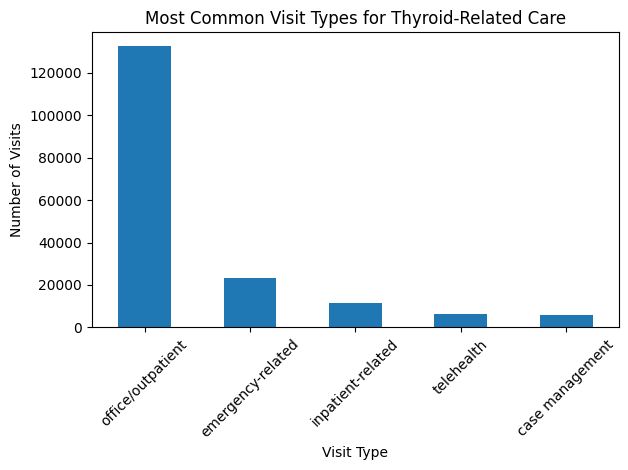

In [28]:
visit_type_count.plot(kind = "bar")

plt.title("Most Common Visit Types for Thyroid-Related Care")
plt.xlabel("Visit Type")
plt.ylabel("Number of Visits")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

## 1B. Are certain thyroid diagnoses more likely to appear in specific visit types?

- We will proceed to use the "visits_thyroid" data as that data only contains thyroid-related cases
- We will combine that data with visit types
- I will find a way for the graph to show which specific thryroid dx appear in which visit types to see it better visually**

## We will create a table that counts how OFTEN each thryoid diagnosis happens in each visit type
- pd.crosstab() = creates a table that counts how often 2 things occur together

- We will have 2 main columns:
    1. Diagnosis = condition_description_clean column
    2. Visit Type = visit_type_group column

-Might change name "diagnosis_by_visit_percent" later since it doesnt include 'normalize="index"
-- if not using it name it instead --> "diagnosis_by_visit_count"

### We will create a contigency table to be able to visualize the raw data by dx and visit types (come back to make sure this is what table is for)
- creates a table of counts
- rows = thyroid dx
- columns = visit types
- values spit out = tell us how many times they occur together

In [29]:
diagnosis_by_visit_type_counts = pd.crosstab( 
    thyroid_only_visits["condition_description_clean"],
    thyroid_only_visits["visit_type_group"]
)

print(diagnosis_by_visit_type_counts)

visit_type_group             Case Management  Emergency-Related  \
condition_description_clean                                       
Disorder of thyroid gland                 61                320   
Hyperthyroidism                          694                791   
Hypothyroidism                          5280              22009   

visit_type_group             Inpatient-Related  Office/Outpatient  Telehealth  
condition_description_clean                                                    
Disorder of thyroid gland                  127               4162         137  
Hyperthyroidism                            300               7447         742  
Hypothyroidism                           11106             120710        5238  


Results provide us with "how often EACH dx appears in EACH visit type"

### Will now take this raw data and convert it to percentages to provide a better visual

Row-wise proportions:

- we will now convert the counts into --> PERCENTAGES for cleaner data
- each row should add up to 100%
- the "normalize = index" = tells code to normalize by row (can add more explanation on why I used it later when I do more research)
- Results:
    - will tell us --> For EACH dx, show how it's DISTRIBUTED across visit types
    - helps to answer orginal question of -->"Are certain dx more likely in specific visit types?"

In [44]:
diagnosis_by_visit_type_percent = pd.crosstab( 
    thyroid_only_visits["condition_description_clean"],
    thyroid_only_visits["visit_type_group"],
    normalize = "index"
) * 100

print(diagnosis_by_visit_type_percent.round(2))

visit_type_group             Case Management  Emergency-Related  \
condition_description_clean                                       
Disorder of thyroid gland               1.27               6.66   
Hyperthyroidism                         6.96               7.93   
Hypothyroidism                          3.21              13.39   

visit_type_group             Inpatient-Related  Office/Outpatient  Telehealth  
condition_description_clean                                                    
Disorder of thyroid gland                 2.64              86.58        2.85  
Hyperthyroidism                           3.01              74.66        7.44  
Hypothyroidism                            6.76              73.45        3.19  


### Column-wise Proportions (optional- may delete later)
- converts data so each column adds up to 100%
    - this is done by "normalize = columns"
    - normalizes by column
- Results:
    - Will tell you --> for EACH visit type, show WHICH dx appear

In [31]:
diagnosis_by_visit_type_column_percent = pd.crosstab(
    thyroid_only_visits["condition_description_clean"],
    thyroid_only_visits["visit_type_group"],
    normalize = "columns"
) * 100

print(diagnosis_by_visit_type_column_percent.round(2))

visit_type_group             Case Management  Emergency-Related  \
condition_description_clean                                       
Disorder of thyroid gland               1.01               1.38   
Hyperthyroidism                        11.50               3.42   
Hypothyroidism                         87.49              95.19   

visit_type_group             Inpatient-Related  Office/Outpatient  Telehealth  
condition_description_clean                                                    
Disorder of thyroid gland                  1.1               3.15        2.24  
Hyperthyroidism                            2.6               5.63       12.13  
Hypothyroidism                            96.3              91.23       85.63  


### Will create Chi-Square Test to determine if there's any assocaition between diagnosis and visit type

In [33]:
from scipy.stats import chi2_contingency

In [34]:
chi2, p, dof, expected = chi2_contingency(diagnosis_by_visit_type_counts)

print("Chi-Square Statistic", chi2)
print("Degrees of freedom", dof)
print("p-value", p)

Chi-Square Statistic 1751.3407981270245
Degrees of freedom 8
p-value 0.0


- Checking that chi square results match or are correct (they are!)
- DELETE LATER

In [37]:
print(diagnosis_by_visit_type_counts.shape)

(3, 5)


In [40]:
rows, cols = diagnosis_by_visit_type_counts.shape

print("Rows:", rows)
print("Columns:", cols)

Rows: 3
Columns: 5


In [41]:
calculated_df = (rows-1)*(cols-1)

print("Calculated df", calculated_df)

Calculated df 8


In [42]:
print("Degrees of freedom", dof)

Degrees of freedom 8


In [43]:
rows, cols = diagnosis_by_visit_type_counts.shape

calculated_df = (rows - 1) * (cols - 1)

print("Rows:", rows)
print("Columns:", cols)
print("Calculated df:", calculated_df)
print("Chi-square df:", dof)

Rows: 3
Columns: 5
Calculated df: 8
Chi-square df: 8


## Will now create a Visual Representation of the Data 

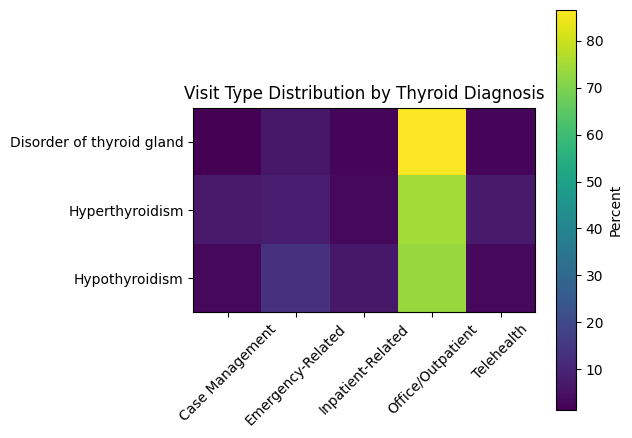

In [45]:
plt.imshow(diagnosis_by_visit_type_percent)
plt.colorbar(label = "Percent")

plt.xticks(
    range(len(diagnosis_by_visit_type_percent.columns)),
    diagnosis_by_visit_type_percent.columns,
    rotation = 45
)

plt.yticks(
    range(len(diagnosis_by_visit_type_percent.index)),
    diagnosis_by_visit_type_percent.index
)

plt.title("Visit Type Distribution by Thyroid Diagnosis")

plt.tight_layout()
plt.savefig("diagnosis_visit_types_heatmap.png")
plt.show()

<Axes: xlabel='visit_type_group'>

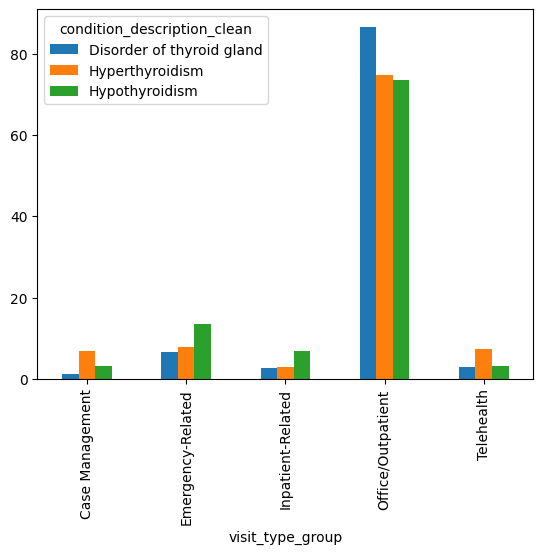

In [51]:
diagnosis_by_visit_type_percent.T.plot(kind="bar")